
# 🌍 GROW Dataset Explorer: Building Towards a Groundwater Foundation Model for Africa

**Objective:** Explore the GROW dataset (Bäthge et al., 2026) to understand its structure, assess African data availability, and lay the groundwork for building a groundwater dynamics foundation model.

**Paper:** A Global-Scale Time Series Dataset for Groundwater Studies within the Earth System (Nature Scientific Data, 2026)

**Dataset:** https://doi.org/10.5281/zenodo.15149480

---


## Phase 1: Setup and Data Download

In [1]:
# Install required packages
!pip install pyarrow fastparquet geopandas matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 73.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully!')

Libraries loaded successfully!


### Download GROW Dataset from Zenodo

⚠️ **Important:** The GROW dataset is large. We'll download the **attributes table** first (smaller) to explore metadata, then selectively load time series.

**Manual step:** Go to https://doi.org/10.5281/zenodo.15149480 and download:
1. `GROW_attributes.parquet` (small, ~50MB)
2. `GROW_timeseries.parquet` (large, several GB)

Upload `GROW_attributes.parquet` to your Google Drive or Colab files first.

Alternatively, if the Zenodo API allows direct download:

In [2]:
# Download directly to Colab (check exact URL from Zenodo page)
!wget -O /content/GROW_attributes.parquet 'https://zenodo.org/records/15149480'

--2026-04-06 12:19:28--  https://zenodo.org/records/15149480
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.48.75, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 138357 (135K) [text/html]
Saving to: ‘/content/GROW_attributes.parquet’

/content/GROW_attri 100%[===================>] 135.11K   274KB/s    in 0.5s    

2026-04-06 12:19:30 (274 KB/s) - ‘/content/GROW_attributes.parquet’ saved [138357/138357]



In [3]:
!wget -O /content/data.zip 'https://zenodo.org/records/15149480/files/data.zip?download=1'

--2026-04-06 12:19:51--  https://zenodo.org/records/15149480/files/data.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.184.98.114, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3587444108 (3.3G) [application/octet-stream]
Saving to: ‘/content/data.zip’

/content/data.zip   100%[===================>]   3.34G  17.4MB/s    in 3m 21s  

2026-04-06 12:23:13 (17.0 MB/s) - ‘/content/data.zip’ saved [3587444108/3587444108]



In [4]:
!unzip /content/data.zip -d /content/GROW/

Archive:  /content/data.zip
   creating: /content/GROW/data/
  inflating: /content/GROW/data/grow_attributes.csv  
  inflating: /content/GROW/data/grow_attributes.json  
  inflating: /content/GROW/data/grow_attributes.parquet  
  inflating: /content/GROW/data/grow_timeseries.csv  
  inflating: /content/GROW/data/grow_timeseries.parquet  


In [5]:
!ls /content/GROW/

data


In [6]:
import pandas as pd

df_attr = pd.read_parquet('/content/GROW/data/grow_attributes.parquet')
print(f'Total wells: {len(df_attr):,}')
print(f'Columns: {len(df_attr.columns)}')
print(f'\nFirst few column names:')
for i, col in enumerate(df_attr.columns):
    print(f'  {i+1}. {col}')

Total wells: 204,292
Columns: 54

First few column names:
  1. GROW_ID
  2. original_ID_groundwater
  3. name
  4. feature_type
  5. purpose
  6. status
  7. description
  8. latitude
  9. longitude
  10. provider_ground_elevation_m_asl
  11. top_of_well_elevation_m_asl
  12. total_drilling_depth_m
  13. country
  14. address
  15. aquifer_name
  16. confinement
  17. organisation
  18. manager
  19. license
  20. interval
  21. aggregated_from_n_values_median
  22. starting_date
  23. ending_date
  24. length_years
  25. autocorrelation
  26. gap_fraction
  27. negative_signs_wtd
  28. outliers_change_points
  29. plateaus
  30. trend_direction
  31. trend_slope_m_year-1
  32. reference_point
  33. groundwater_mean_m
  34. groundwater_median_m
  35. koeppen_geiger_class
  36. hydrobelt_class
  37. ground_elevation_merit_m_asl
  38. topographic_slope_degree
  39. rock_type_0-100_m_class
  40. aquifer_type_class
  41. permeability_0-100_m_m-2
  42. total_porosity_0-100_m_fraction
  43. 

In [7]:
print(f'\nCountries: {df_attr["country"].nunique()}')
print(f'\nTop 10 countries:')
print(df_attr['country'].value_counts().head(10))


Countries: 55

Top 10 countries:
country
USA    101003
IND     33814
AUS     21384
FRA     13314
MEX      7433
ESP      3602
DNK      3395
ZAF      3301
NZL      2478
NLD      2383
Name: count, dtype: int64


In [8]:
# Check all unique countries to find African ones
print('\nAll countries in GROW:')
for c in sorted(df_attr['country'].unique()):
    print(f'  {c}')


All countries in GROW:
  AFG
  AUS
  AUT
  BEL
  BGR
  BRA
  CAN
  CHE
  CHL
  CHN
  CRI
  CUB
  CZE
  DEU
  DNK
  ESP
  EST
  FIN
  FRA
  GBR
  GMB
  HRV
  IND
  IRL
  ISR
  ITA
  JAM
  KOR
  LSO
  LTU
  LUX
  LVA
  MDG
  MEX
  MOZ
  MYS
  NAM
  NGA
  NLD
  NOR
  NPL
  NZL
  PRT
  PSE
  RWA
  SLE
  SLV
  SOM
  SVN
  SWE
  THA
  TWN
  UGA
  USA
  ZAF


In [9]:
!rm /content/data.zip

In [10]:
african_codes = ['GMB', 'LSO', 'MDG', 'MOZ', 'NAM', 'NGA', 'RWA', 'SLE', 'SOM', 'UGA', 'ZAF']

df_africa = df_attr[df_attr['country'].isin(african_codes)]

print(f'African wells: {len(df_africa):,}')
print(f'Percentage of total: {len(df_africa)/len(df_attr)*100:.2f}%')
print(f'\nAfrican countries found:')
print(df_africa['country'].value_counts())
print(f'\nFor context:')
print(f'  GMB = Gambia')
print(f'  LSO = Lesotho')
print(f'  MDG = Madagascar')
print(f'  MOZ = Mozambique')
print(f'  NAM = Namibia')
print(f'  NGA = Nigeria')
print(f'  RWA = Rwanda')
print(f'  SLE = Sierra Leone')
print(f'  SOM = Somalia')
print(f'  UGA = Uganda')
print(f'  ZAF = South Africa')

African wells: 3,538
Percentage of total: 1.73%

African countries found:
country
ZAF    3301
NAM      84
RWA      43
GMB      36
LSO      16
MOZ      14
NGA      14
UGA      10
MDG      10
SLE       6
SOM       4
Name: count, dtype: int64

For context:
  GMB = Gambia
  LSO = Lesotho
  MDG = Madagascar
  MOZ = Mozambique
  NAM = Namibia
  NGA = Nigeria
  RWA = Rwanda
  SLE = Sierra Leone
  SOM = Somalia
  UGA = Uganda
  ZAF = South Africa


In [11]:
print('GLOBAL vs AFRICA COMPARISON')
print('='*50)

# Climate zones
print('\nClimate zones (Global):')
print(df_attr['koeppen_geiger_class'].value_counts().head(10))
print('\nClimate zones (Africa):')
print(df_africa['koeppen_geiger_class'].value_counts())

# Aquifer types
print('\nAquifer types (Global):')
print(df_attr['aquifer_type_class'].value_counts())
print('\nAquifer types (Africa):')
print(df_africa['aquifer_type_class'].value_counts())

# Time series length
print(f'\nMedian time series length (Global): {df_attr["length_years"].median():.1f} years')
print(f'Median time series length (Africa): {df_africa["length_years"].median():.1f} years')

# Groundwater depth
print(f'\nMedian groundwater depth (Global): {df_attr["groundwater_median_m"].median():.1f} m')
print(f'Median groundwater depth (Africa): {df_africa["groundwater_median_m"].median():.1f} m')

# Trends
print('\nTrend direction (Global):')
print(df_attr['trend_direction'].value_counts())
print('\nTrend direction (Africa):')
print(df_africa['trend_direction'].value_counts())

GLOBAL vs AFRICA COMPARISON

Climate zones (Global):
koeppen_geiger_class
BSk     33853
Cfb     26707
LCsb    26610
Cfa     26292
Csa     25474
Aw      19046
BSh     11779
Cwa     11744
BWh      5431
Dfa      5076
Name: count, dtype: int64

Climate zones (Africa):
koeppen_geiger_class
BSk     953
BSh     826
Cwb     505
Cfb     332
BWh     231
LCsb    180
Csa     166
Cwa     100
Aw       74
BWk      69
Cfa      47
As       32
Am       17
Af        6
Name: count, dtype: int64

Aquifer types (Global):
aquifer_type_class
porous              81486
fractured           42543
porous/fractured    39982
karst               27751
water_body           5346
Name: count, dtype: int64

Aquifer types (Africa):
aquifer_type_class
porous/fractured    1344
fractured            730
karst                693
porous               626
water_body             6
Name: count, dtype: int64

Median time series length (Global): 10.0 years
Median time series length (Africa): 6.0 years

Median groundwater depth (Glob

In [12]:
# Save the Africa analysis
summary = {
    'total_global_wells': len(df_attr),
    'total_african_wells': len(df_africa),
    'african_percentage': len(df_africa)/len(df_attr)*100,
    'african_countries': len(df_africa['country'].unique()),
    'nigeria_wells': len(df_africa[df_africa['country']=='NGA']),
    'usa_wells': len(df_attr[df_attr['country']=='USA']),
    'median_depth_global': df_attr['groundwater_median_m'].median(),
    'median_depth_africa': df_africa['groundwater_median_m'].median(),
    'median_length_global': df_attr['length_years'].median(),
    'median_length_africa': df_africa['length_years'].median(),
}

import json
with open('/content/grow_africa_assessment.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Summary saved!')
print(json.dumps(summary, indent=2))

Summary saved!
{
  "total_global_wells": 204292,
  "total_african_wells": 3538,
  "african_percentage": 1.7318348246627375,
  "african_countries": 11,
  "nigeria_wells": 14,
  "usa_wells": 101003,
  "median_depth_global": 8.400288,
  "median_depth_africa": 13.421,
  "median_length_global": 10.0,
  "median_length_africa": 6.0
}


Phase 2: baseline models.

In [13]:
import pyarrow.parquet as pq

# Read only the schema (no data loaded into memory)
schema = pq.read_schema('/content/GROW/data/grow_timeseries.parquet')
print('Time series columns:')
for i, name in enumerate(schema.names):
    print(f'  {i+1}. {name}')

Time series columns:
  1. GROW_ID
  2. interval
  3. date
  4. year
  5. month
  6. aggregated_from_n_values
  7. outliers_change_points
  8. plateaus
  9. groundwater_depth_from_ground_elevation_m
  10. groundwater_depth_from_well_top_elevation_m
  11. groundwater_water_level_elevation_m_asl
  12. groundwater_filled_depth_from_ground_elevation_m
  13. groundwater_filled_depth_from_well_top_elevation_m
  14. groundwater_filled_water_level_elevation_m_asl
  15. precipitation_mswep_mm_year-1
  16. precipitation_gpcc_mm_year-1
  17. potential_evapotranspiration_era5_mm_year-1
  18. potential_evapotranspiration_gleam_mm_year-1
  19. actual_evapotranspiration_mm_year-1
  20. interception_mm_year-1
  21. air_temperature_°C
  22. snow_depth_m
  23. days_with_snow_cover_days_year-1
  24. ndvi_ratio
  25. lai_low_vegetation_ratio
  26. lai_high_vegetation_ratio
  27. withdrawal_industrial_m3_year-1
  28. withdrawal_domestic_m3_year-1
  29. urban_area_fraction
  30. pastures_fraction
  31. cropl

In [14]:
import pandas as pd

# Get 10,000 yearly wells
yearly_wells = df_attr[df_attr['interval'] == 'YS']['GROW_ID'].tolist()[:10000]

df_ts = pd.read_parquet(
    '/content/GROW/data/grow_timeseries.parquet',
    filters=[('GROW_ID', 'in', yearly_wells)],
    columns=[
        'GROW_ID', 'year',
        'groundwater_depth_from_ground_elevation_m',
        'precipitation_mswep_mm_year-1',
        'precipitation_gpcc_mm_year-1',
        'potential_evapotranspiration_era5_mm_year-1',
        'actual_evapotranspiration_mm_year-1',
        'air_temperature_°C',
        'ndvi_ratio',
        'withdrawal_domestic_m3_year-1',
        'withdrawal_industrial_m3_year-1',
        'urban_area_fraction',
        'cropland_irrigated_fraction',
        'forests_natural_vegetation_fraction'
    ]
)

print(f'Rows: {len(df_ts):,}')
print(f'Unique wells: {df_ts["GROW_ID"].nunique():,}')
print(f'Memory: {df_ts.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'\nYear range: {df_ts["year"].min()} - {df_ts["year"].max()}')
print(f'\nMissing values:')
print(df_ts.isnull().sum())

Rows: 100,352
Unique wells: 10,000
Memory: 17 MB

Year range: 1964 - 2025

Missing values:
GROW_ID                                            0
year                                               0
groundwater_depth_from_ground_elevation_m       2516
precipitation_mswep_mm_year-1                     78
precipitation_gpcc_mm_year-1                   23024
potential_evapotranspiration_era5_mm_year-1     3695
actual_evapotranspiration_mm_year-1            11211
air_temperature_°C                              3695
ndvi_ratio                                       562
withdrawal_domestic_m3_year-1                  17596
withdrawal_industrial_m3_year-1                17596
urban_area_fraction                            17702
cropland_irrigated_fraction                    17702
forests_natural_vegetation_fraction            17702
dtype: int64


In [15]:
# Merge static Earth system attributes with time series
static_features = [
    'GROW_ID', 'ground_elevation_merit_m_asl', 'topographic_slope_degree',
    'permeability_0-100_m_m-2', 'total_porosity_0-100_m_fraction',
    'soil_saturated_conductivity_0-30_cm_cm_d-1',
    'distance_perennial_streams_m', 'drainage_density_m-1',
    'days_with_snow_cover_average_days_year-1'
]

df_merged = df_ts.merge(df_attr[static_features], on='GROW_ID', how='left')

# Define target and features
target = 'groundwater_depth_from_ground_elevation_m'

features = [
    'precipitation_mswep_mm_year-1',
    'potential_evapotranspiration_era5_mm_year-1',
    'air_temperature_°C',
    'ndvi_ratio',
    'ground_elevation_merit_m_asl',
    'topographic_slope_degree',
    'permeability_0-100_m_m-2',
    'total_porosity_0-100_m_fraction',
    'soil_saturated_conductivity_0-30_cm_cm_d-1',
    'distance_perennial_streams_m',
    'drainage_density_m-1'
]

# Drop rows with missing target or features
df_model = df_merged[features + [target]].dropna()
print(f'Rows after dropping NaN: {len(df_model):,}')

X = df_model[features]
y = df_model[target]

print(f'Features: {X.shape[1]}')
print(f'Samples: {X.shape[0]:,}')

Rows after dropping NaN: 92,430
Features: 11
Samples: 92,430


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb
import numpy as np

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train XGBoost
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'\n{"="*50}')
print(f'BASELINE MODEL RESULTS')
print(f'{"="*50}')
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.2f} metres')
print(f'Train samples: {len(X_train):,}')
print(f'Test samples: {len(X_test):,}')

[0]	validation_0-rmse:9.21710
[50]	validation_0-rmse:7.79925
[100]	validation_0-rmse:7.48840
[150]	validation_0-rmse:7.27052
[200]	validation_0-rmse:7.14317
[250]	validation_0-rmse:7.04057
[300]	validation_0-rmse:6.95101
[350]	validation_0-rmse:6.86957
[400]	validation_0-rmse:6.79946
[450]	validation_0-rmse:6.75253
[499]	validation_0-rmse:6.70637

BASELINE MODEL RESULTS
R² Score: 0.4794
MAE: 2.60 metres
Train samples: 73,944
Test samples: 18,486


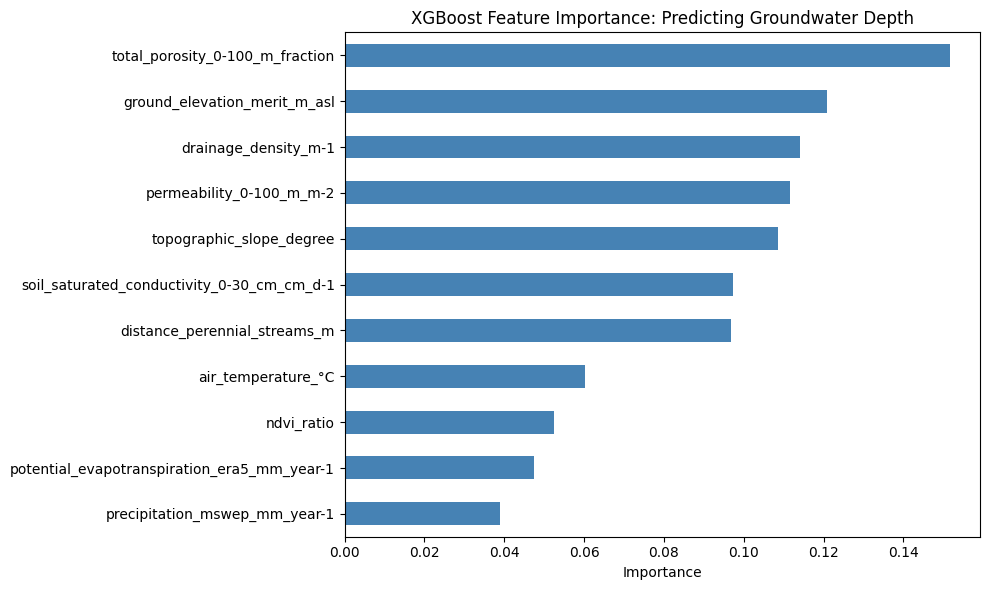


Top 5 features:
  topographic_slope_degree: 0.1085
  permeability_0-100_m_m-2: 0.1115
  drainage_density_m-1: 0.1141
  ground_elevation_merit_m_asl: 0.1209
  total_porosity_0-100_m_fraction: 0.1516


In [17]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance: Predicting Groundwater Depth')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('/content/feature_importance_baseline.png', dpi=150)
plt.show()

print('\nTop 5 features:')
for feat, imp in importance.tail(5).items():
    print(f'  {feat}: {imp:.4f}')

In [18]:
# How well does a model trained on ALL data predict specific climate zones?
df_eval = df_merged[features + [target, 'GROW_ID']].dropna()
df_eval = df_eval.merge(df_attr[['GROW_ID', 'koeppen_geiger_class']], on='GROW_ID')

y_pred_all = model.predict(df_eval[features])
df_eval['predicted'] = y_pred_all
df_eval['error'] = abs(df_eval[target] - df_eval['predicted'])

print('MAE by climate zone (top 10):')
climate_mae = df_eval.groupby('koeppen_geiger_class')['error'].agg(['mean', 'count'])
climate_mae = climate_mae[climate_mae['count'] >= 100].sort_values('mean')
climate_mae.columns = ['MAE (m)', 'Samples']
print(climate_mae.head(10))
print('\nWorst performing:')
print(climate_mae.tail(5))

MAE by climate zone (top 10):
                       MAE (m)  Samples
koeppen_geiger_class                   
Am                    1.445762    26422
As                    1.989636     1249
Aw                    2.396898    45950
BSh                   2.451566    18640

Worst performing:
                       MAE (m)  Samples
koeppen_geiger_class                   
Am                    1.445762    26422
As                    1.989636     1249
Aw                    2.396898    45950
BSh                   2.451566    18640


In [19]:
print('='*50)
print('SESSION SUMMARY: PHASE 2 BASELINE')
print('='*50)
print(f'''
Dataset: GROW (Baethge et al., 2026)
Subset: 10,000 yearly wells, 92,430 samples

BASELINE MODEL: XGBoost
  R² Score: 0.4794
  MAE: 2.60 metres
  Features: 11 Earth system variables

KEY FINDING: Geological variables dominate
  1. Total porosity (0.1516)
  2. Ground elevation (0.1209)
  3. Drainage density (0.1141)
  4. Permeability (0.1115)
  5. Topographic slope (0.1085)

IMPLICATION: Subsurface properties control
groundwater depth more than atmospheric forcing
at the global scale. This suggests a foundation
model must learn geology-aware representations
to transfer effectively to new regions.

NEXT: Test performance across climate zones
to identify transfer learning challenges.
''')

SESSION SUMMARY: PHASE 2 BASELINE

Dataset: GROW (Baethge et al., 2026)
Subset: 10,000 yearly wells, 92,430 samples

BASELINE MODEL: XGBoost
  R² Score: 0.4794
  MAE: 2.60 metres
  Features: 11 Earth system variables

KEY FINDING: Geological variables dominate
  1. Total porosity (0.1516)
  2. Ground elevation (0.1209)
  3. Drainage density (0.1141)
  4. Permeability (0.1115)
  5. Topographic slope (0.1085)

IMPLICATION: Subsurface properties control 
groundwater depth more than atmospheric forcing
at the global scale. This suggests a foundation 
model must learn geology-aware representations
to transfer effectively to new regions.

NEXT: Test performance across climate zones
to identify transfer learning challenges.



In [20]:
# Lower the threshold and check all zones
climate_mae = df_eval.groupby('koeppen_geiger_class')['error'].agg(['mean', 'count'])
climate_mae = climate_mae.sort_values('mean')
climate_mae.columns = ['MAE (m)', 'Samples']
print('ALL climate zones:')
print(climate_mae)
print(f'\nTotal climate zones: {len(climate_mae)}')

ALL climate zones:
                       MAE (m)  Samples
koeppen_geiger_class                   
Cwb                   1.006119       47
Cfb                   1.197973       60
Am                    1.445762    26422
Cwa                   1.473011       62
As                    1.989636     1249
Aw                    2.396898    45950
BSh                   2.451566    18640

Total climate zones: 7


In [21]:
print('='*60)
print('GWATER-FM: PHASE 1-2 COMPLETE')
print('='*60)
print(f'''
DATE: April 2026
DATASET: GROW (Baethge et al., 2026)
  Total global wells: 204,292
  African wells: 3,538 (1.73%)
  Nigeria wells: 14

BASELINE MODEL: XGBoost (10,000 well subset)
  R² Score: 0.4794
  MAE: 2.60 metres
  Features: 11 Earth system variables

TOP FEATURES (geological dominance):
  1. Total porosity: 0.1516
  2. Ground elevation: 0.1209
  3. Drainage density: 0.1141
  4. Permeability: 0.1115
  5. Topographic slope: 0.1085

CLIMATE ZONE PERFORMANCE:
  Best:  Cwb (humid subtropical) - 1.0m MAE
  Worst: BSh (semi-arid hot) - 2.5m MAE

CRITICAL INSIGHT: Semi-arid zones where Africa
needs predictions most are where the model
performs worst. This confirms transfer learning
must be climate-aware, not climate-blind.

NEXT STEPS:
  - Stratified sampling across all climate zones
  - Add temporal features (lagged precipitation)
  - LSTM baseline for temporal dynamics
  - Test explicit train-on-temperate,
    predict-on-arid transfer experiment
''')

GWATER-FM: PHASE 1-2 COMPLETE

DATE: April 2026
DATASET: GROW (Baethge et al., 2026)
  Total global wells: 204,292
  African wells: 3,538 (1.73%)
  Nigeria wells: 14

BASELINE MODEL: XGBoost (10,000 well subset)
  R² Score: 0.4794
  MAE: 2.60 metres
  Features: 11 Earth system variables

TOP FEATURES (geological dominance):
  1. Total porosity: 0.1516
  2. Ground elevation: 0.1209
  3. Drainage density: 0.1141
  4. Permeability: 0.1115
  5. Topographic slope: 0.1085

CLIMATE ZONE PERFORMANCE:
  Best:  Cwb (humid subtropical) - 1.0m MAE
  Worst: BSh (semi-arid hot) - 2.5m MAE
  
CRITICAL INSIGHT: Semi-arid zones where Africa
needs predictions most are where the model 
performs worst. This confirms transfer learning
must be climate-aware, not climate-blind.

NEXT STEPS:
  - Stratified sampling across all climate zones
  - Add temporal features (lagged precipitation)
  - LSTM baseline for temporal dynamics
  - Test explicit train-on-temperate, 
    predict-on-arid transfer experiment

